# Example: Solving Helmholtz Equation for a scattering problem

$$ (\nabla^2 + k^2)u = b$$

In [3]:
%matplotlib ipympl

In [4]:
import sympy as sym
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import scipy as sp
import importlib

In [5]:
import sys
sys.path.append('../../modules')
from helmholtz_equation import sources, pml_conditions, domains, plotting, analysis
importlib.reload(plotting)

<module 'helmholtz_equation.plotting' from 'c:\\Users\\jasolanoz\\Documents\\GitHub\\seismic_wave_propagation\\notebooks\\examples\\../../modules\\helmholtz_equation\\plotting.py'>

## 1. Domain

In [6]:
main_domain_shape = (201, 201)
main_domain_extension = (-0.5, 0.5, -0.5, 0.5)
domain = domains.HelmholtzDomain(main_domain_shape, main_domain_extension)
domain.pml_domain(150)

## 2. Parameters

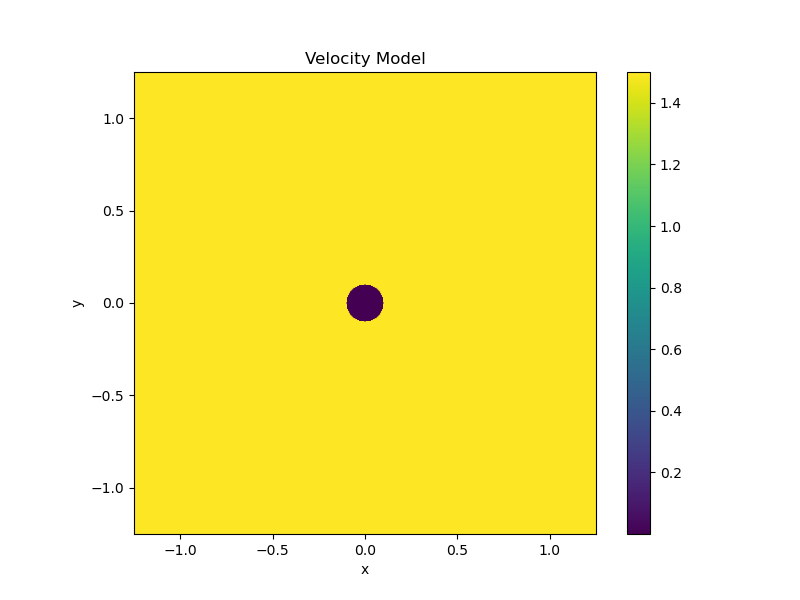

In [7]:
#frequency_array = np.linspace(1, 20, 20)
frequency_array = np.array([5, 10])
#frequency_array = np.array([5, 10, 15, 20, 25])

nfrequencies = np.size(frequency_array)

alpha = 1.4

velocity = 1.5
velocity_array = np.ones((domain.nx, domain.ny))*velocity
cv2.circle(velocity_array, (domain.nx//2, domain.ny//2), 20, 1e-4, -1)
# cv2.circle(velocity_array, (domain.nx//2, 2*domain.ny//5), 20, 1e-4, -1)
# cv2.circle(velocity_array, (domain.nx//2, 3*domain.ny//5), 20, 1e-4, -1)

plotting.plot_velocity(domain, velocity_array)

### Source

In [8]:
source = sources.PlaneWaveSource(amplitude=1, phase=0, x_range=1, y_pos=domain.y_array[domain.nbl])

## 3. Solver

In [9]:
u_arrays = np.zeros((domain.nx, domain.ny, nfrequencies), dtype=complex)
b_arrays = np.zeros((domain.nx, domain.ny, nfrequencies), dtype=complex)

In [10]:
for i, this_frequency in enumerate(frequency_array):
    u_arrays[..., i], b_arrays[..., i] = pml_conditions.helmholtz_pml_solution(domain, this_frequency, velocity_array, source, alpha)

Se soluciona el campo en cartesianas
Se soluciona el campo en cartesianas


## 4. Plotting

In [17]:
this_nfrequency = 0

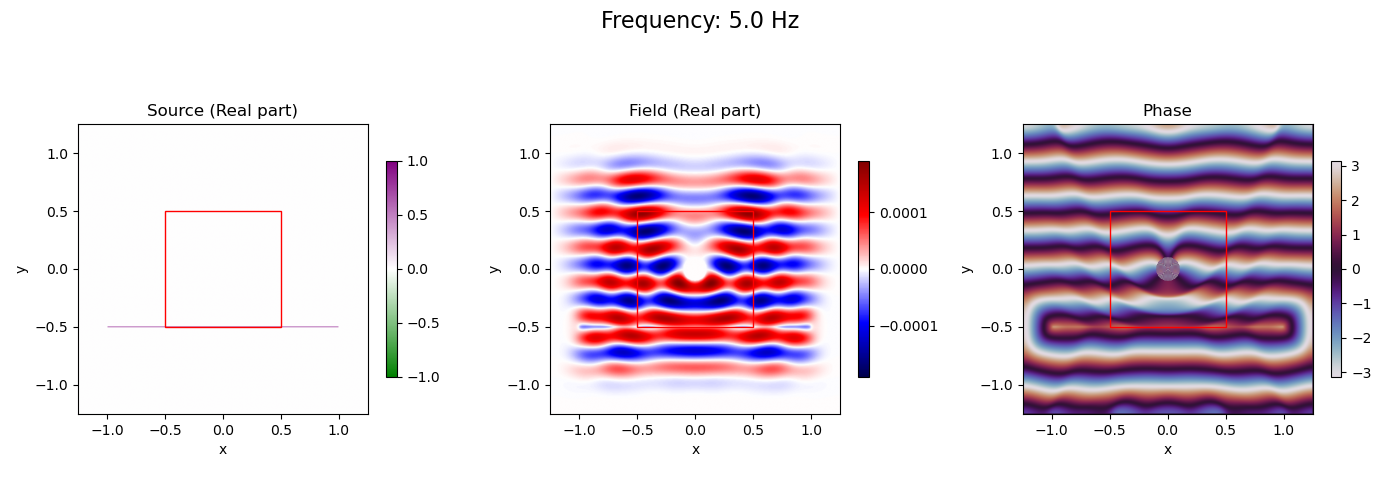

In [18]:
plotting.plot_solution(domain, frequency_array, this_nfrequency, u_arrays, b_arrays)

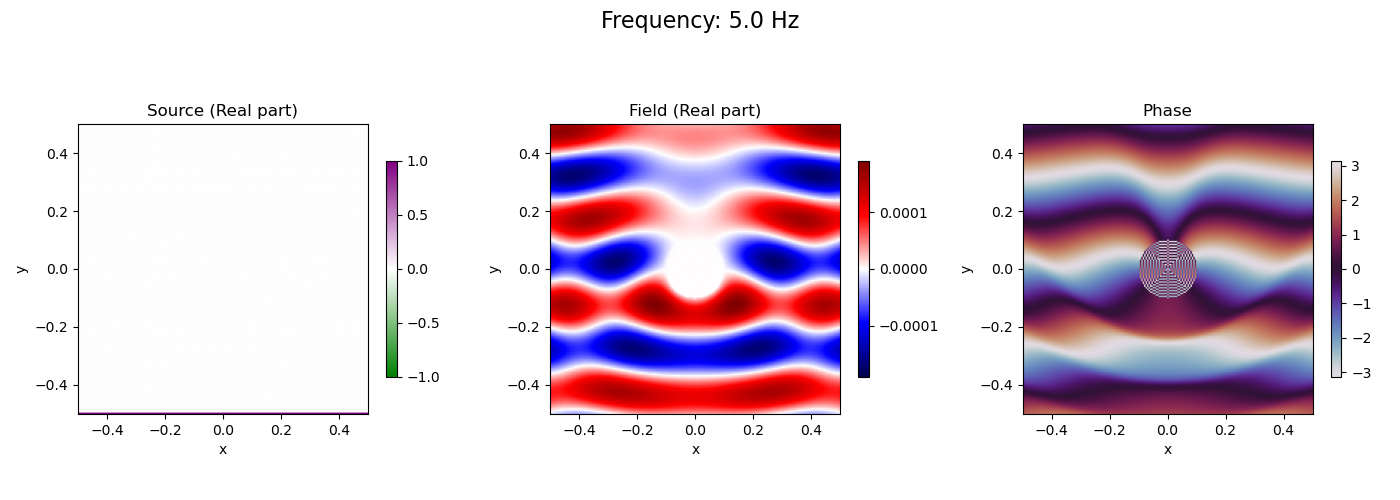

In [19]:
plotting.plot_main_solution(domain, frequency_array, this_nfrequency, u_arrays, b_arrays)